# Xây dựng Mô hình Phân loại và Dự báo Rủi ro Khách hàng Vay vốn

**Notebook 03/07 - Data Cleaning (Làm sạch dữ liệu)**

---

**Mục tiêu:** Biến bảng `application_flat` (đã tích hợp từ PostgreSQL ở Notebook 02) thành dữ liệu sạch, nhất quán, sẵn sàng cho EDA và Feature Engineering. Dữ liệu "sạch" gồm bốn ý: không còn thiếu, không còn trùng lặp, không sai logic, đủ và rõ nghĩa.

**Input:** bảng `application_flat` trong PostgreSQL (307.511 dòng x 148 cột), đọc bằng `pd.read_sql()`.

**Output:** bảng `application_flat_cleaned` trong PostgreSQL, sẵn sàng cho Notebook 04.

**Pipeline:** Notebook 02 - Database Organization -> **Notebook 03 - Data Cleaning** -> Notebook 04 - EDA & Visualization

## 1. Giới thiệu

### 1.1. Mục tiêu và vai trò của Data Cleaning

Notebook 02 đã tổ chức toàn bộ dữ liệu raw vào PostgreSQL và tạo bảng `application_flat` bằng cách gom 5 bảng phụ (`bureau`, `previous_application`, `installments_payments`, `pos_cash_balance`, `credit_card_balance`) về mức một dòng cho mỗi khách hàng rồi `LEFT JOIN` với `application_train`. Notebook 03 nhận bảng này làm đầu vào và có vai trò biến nó thành dữ liệu sạch, nhất quán, sẵn sàng cho Notebook 04 (EDA) và Notebook 05 (Feature Engineering).

Dữ liệu được coi là "sạch" khi đạt bốn tiêu chí: không còn thiếu dữ liệu vô lý, không còn trùng lặp, không còn giá trị sai logic, và đủ/rõ nghĩa cho phân tích.

### 1.2. Vì sao Notebook 03 chỉ làm sạch một bảng phẳng

`application_flat` đã gộp dữ liệu của cả 5 bảng phụ dưới dạng các nhóm cột (`bureau_*`, `previous_*`, `installments_*`, `pos_cash_*`, `credit_card_*`). Làm sạch theo từng nhóm cột này tương đương với việc làm sạch từng bảng phụ, chỉ khác là thực hiện trên dữ liệu đã tổng hợp thay vì từng dòng raw.

Nếu làm sạch từng bảng raw trước rồi mới join, toàn bộ bước tổng hợp (`GROUP BY`, `SUM`, `AVG`) ở Notebook 02 phải làm lại, không có lợi ích tương xứng. Điểm đánh đổi cần nêu rõ: một số giá trị sai logic ở tầng raw (ví dụ dòng nợ âm trong bảng `bureau`) đã bị `SUM` gộp lại trước khi tới Notebook 03, nên notebook này chỉ xử lý được ở mức giá trị tổng đã gom, không xử lý được từng dòng raw gốc.

### 1.3. Data Cleaning Pipeline

```
PostgreSQL -> Read SQL -> Đánh giá chất lượng ban đầu -> Missing Values -> Duplicate
-> Outlier -> Logic Validation -> Loại cột trùng lặp -> Đánh giá sau Cleaning
-> Lưu bảng sạch -> Notebook 04 (EDA)
```

## 2. Đọc dữ liệu

### 2.1. Kết nối PostgreSQL và đọc `application_flat`

Đoạn code bên dưới kết nối PostgreSQL bằng `psycopg2` và đọc bảng `application_flat` bằng `pd.read_sql()`.

In [51]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv
from IPython.display import display

# Nếu chạy notebook từ thư mục notebooks/, quay về thư mục gốc dự án.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Thông tin kết nối đọc từ .env ở thư mục gốc, file này không được commit lên GitHub.
load_dotenv(PROJECT_ROOT / ".env")

conn = psycopg2.connect(
    host=os.getenv("DB_HOST", "localhost"),
    port=os.getenv("DB_PORT", "5432"),
    dbname=os.getenv("DB_NAME", "credit_risk_db"),
    user=os.getenv("DB_USER", "postgres"),
    password=os.getenv("DB_PASSWORD"),
)

# pandas gợi ý dùng SQLAlchemy khi đọc bằng psycopg2, đây chỉ là cảnh báo,
# nhóm chủ ý dùng psycopg2 trực tiếp (xem requirements.txt) nên tắt riêng cảnh báo này.
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

df = pd.read_sql("SELECT * FROM application_flat", conn)
print("Shape:", df.shape)

Shape: (307511, 148)


**Nhận xét:** Bảng `application_flat` đọc được từ PostgreSQL đúng 307.511 dòng x 148 cột như Notebook 02 đã bàn giao.

### 2.2. Khảo sát nhanh cấu trúc bảng

Đoạn code bên dưới xem `head()` và `info()` rút gọn để nắm cấu trúc cột trước khi đánh giá chất lượng.

In [24]:
display(df.head())
df.info(verbose=False, memory_usage="deep")

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,pos_cash_count,pos_cash_avg_dpd,pos_cash_max_dpd,pos_cash_oldest_month,pos_cash_latest_month,credit_card_count,credit_card_avg_balance,credit_card_max_balance,credit_card_avg_limit,credit_card_max_dpd
0,176112,0,Cash loans,F,N,N,0.0,108000.0,152820.0,15241.5,...,13.0,0.0,0.0,-28.0,-16.0,NaN,NaN,NaN,NaN,NaN
1,176113,0,Cash loans,F,Y,Y,1.0,225000.0,273636.0,32602.5,...,16.0,0.0,0.0,-88.0,-67.0,NaN,NaN,NaN,NaN,NaN
2,176114,0,Cash loans,M,N,N,0.0,180000.0,239850.0,25960.5,...,19.0,0.0,0.0,-69.0,-28.0,NaN,NaN,NaN,NaN,NaN
3,176115,0,Cash loans,F,N,Y,0.0,214555.5,873000.0,24138.0,...,43.0,0.0,0.0,-57.0,-2.0,NaN,NaN,NaN,NaN,NaN
4,176116,0,Cash loans,F,Y,N,0.0,270000.0,1035000.0,34335.0,...,7.0,0.0,0.0,-51.0,-45.0,8.0,0.0,0.0,84375.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 148 entries, sk_id_curr to credit_card_max_dpd
dtypes: float64(98), int64(34), str(16)
memory usage: 386.2 MB


**Nhận xét:** Bảng gồm 148 cột với nhiều kiểu dữ liệu khác nhau (số, chữ, cờ nhị phân). Với số lượng cột lớn như vậy, bước tiếp theo là phân nhóm cột thay vì khảo sát thủ công từng cột.

## 3. Đánh giá chất lượng ban đầu

Với 148 cột, không xử lý thủ công từng cột mà phân nhóm theo hai chiều: kiểu dữ liệu và mức độ missing, rồi áp dụng quy tắc theo từng nhóm.

### 3.1. Phân nhóm cột theo kiểu dữ liệu

Đoạn code bên dưới phân nhóm cột thành: khóa/nhãn (`sk_id_curr`, `target`), cờ nhị phân (numeric chỉ nhận tối đa 2 giá trị), category dạng chữ, và numeric còn lại. Không có cột kiểu ngày tháng thật — mọi cột `DAYS_*` đều là số nguyên đếm ngược nên đã nằm trong nhóm numeric.

In [25]:
id_cols = ["sk_id_curr"]
target_col = ["target"]

dtype_numeric_all = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Co nhi phan: cot numeric chi nhan toi da 2 gia tri khac NaN (0/1).
binary_flag_cols = [c for c in dtype_numeric_all
                     if c not in id_cols + target_col and df[c].dropna().nunique() <= 2]
# pandas 3 mac dinh doc cot chu ve dtype "str" thay vi "object", can khai bao ca hai.
category_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
numeric_cols = [c for c in dtype_numeric_all
                if c not in binary_flag_cols and c not in id_cols + target_col]

dtype_group_summary = pd.DataFrame({
    "Nhóm cột": ["ID", "Target", "Numeric", "Category (chu)", "Có nhị phân"],
    "Số lượng cột": [len(id_cols), len(target_col), len(numeric_cols), len(category_cols), len(binary_flag_cols)],
})
display(dtype_group_summary)
assert len(id_cols) + len(target_col) + len(numeric_cols) + len(category_cols) + len(binary_flag_cols) == df.shape[1]

,Nhóm cột,Số lượng cột
0,ID,1
1,Target,1
2,Numeric,98
3,Category (chu),16
4,Có nhị phân,32


**Nhận xét:** 98 cột numeric, 32 cột có nhị phân, 16 cột category dạng chữ, cộng với khóa `sk_id_curr` và nhãn `target` là đủ 148 cột. Ba nhóm numeric/category/cờ nhị phân sẽ được áp quy tắc xử lý missing riêng ở Mục 4.

### 3.2. Phân nhóm cột theo tỷ lệ missing

Đoạn code bên dưới tính tỷ lệ missing từng cột và chia thành ba mức: dưới 5%, 5-30%, trên 30%.

Số cột không missing: 55
Số cột có missing: 93


<5%      10
5-30%    28
>30%     55
Name: count, dtype: int64

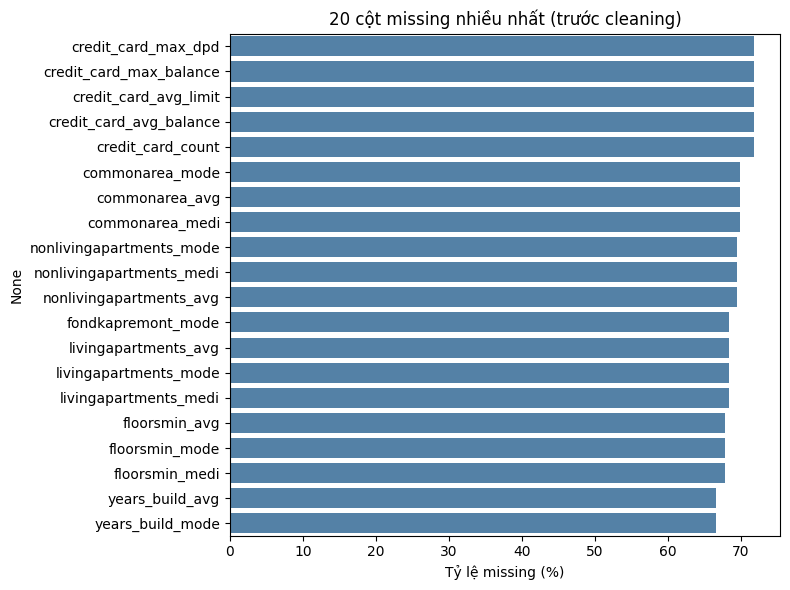

In [26]:
missing_pct_before = df.isna().mean().sort_values(ascending=False) * 100
missing_cols_before = missing_pct_before[missing_pct_before > 0]

missing_bracket = pd.cut(missing_cols_before, bins=[-0.01, 5, 30, 100], labels=["<5%", "5-30%", ">30%"])
print("Số cột không missing:", (missing_pct_before == 0).sum())
print("Số cột có missing:", len(missing_cols_before))
display(missing_bracket.value_counts().reindex(["<5%", "5-30%", ">30%"]))

fig, ax = plt.subplots(figsize=(8, 6))
top20 = missing_cols_before.head(20)
sns.barplot(x=top20.values, y=top20.index, ax=ax, color="steelblue")
ax.set_xlabel("Tỷ lệ missing (%)")
ax.set_title("20 cột missing nhiều nhất (trước cleaning)")
plt.tight_layout()
plt.show()

**Nhận xét:** 93/148 cột có missing (10 cột <5%, 28 cột 5-30%, 55 cột >30%). Nhóm missing cao nhất là các cột `credit_card_*` (71,7%) và các cột nhà ở `_avg`/`_medi`/`_mode` (48-70%). Đây không phải dữ liệu hỏng ngẫu nhiên mà có lý do nghiệp vụ rõ ràng, sẽ giải thích ở Mục 4.

## 4. Xử lý Missing Values

### 4.1. Bảng Cleaning Rule

| Nhóm cột | Số cột | Missing | Phương pháp | Lý do |
|---|---|---|---|---|
| `sk_id_curr`, `target` | 2 | 0% | Không xử lý | Khóa và nhãn, không có missing |
| `*_count` (5 cột summary: bureau/previous/installments/pos_cash/credit_card) | 5 | 5,9-71,7% | Điền `0` + thêm cột cờ `has_<nhom>` | `NULL` nghĩa là khách không có dòng nào ở bảng phụ tương ứng — 0 khoản vay đúng bản chất, không phải thiếu dữ liệu |
| Cột tiền/ngày summary còn lại (21 cột, vd `bureau_sum_credit`, `credit_card_avg_balance`...) | 21 | 5,9-71,7% | Giữ `NaN`, đã có cờ `has_<nhom>` đại diện | Điền median/mean tạo ra lịch sử tín dụng giả cho khách chưa từng vay — làm mất chính tín hiệu "không có lịch sử" |
| `own_car_age` | 1 | 66% | Giữ `NaN` | Missing trùng gần như tuyệt đối với `flag_own_car = 'N'` (khách không có xe) — flag đã có sẵn, điền tuổi xe giả không có ý nghĩa |
| `occupation_type` | 1 | 31,3% | Điền `"Unknown"` | Category, thiếu có thể do khách không khai nghề nghiệp — tách nhãn riêng thay vì mode để tránh thiên lệch |
| Category chữ nhà ở missing cao (`fondkapremont_mode`, `housetype_mode`, `wallsmaterial_mode`, `emergencystate_mode`) | 4 | 45-68% | Điền `"Unknown"` | Missing >30%, coi là một nhóm riêng thay vì áp mode |
| Category chữ missing thấp (`name_type_suite`) | 1 | 0,42% | Điền mode | Missing thấp, mode hợp lý và không lệch phân bố |
| Numeric còn missing (ext_source_1/2/3, amt_annuity, amt_goods_price, cnt_fam_members, các cột nhà ở `_avg`, `totalarea_mode`, social circle, amt_req_credit_bureau_*, days_last_phone_change) | 37 | 0-56% | Điền median | Median bền với outlier hơn mean, phù hợp với các cột tiền/điểm số lệch phải |
| Housing `_medi`/`_mode` numeric trùng lặp | 28 | 48-70% | Không điền — sẽ loại bỏ ở Mục 8 | Trùng lặp thống kê với `_avg`, xử lý dứt điểm ở bước loại cột |

Đoạn code bên dưới áp dụng lần lượt từng dòng quy tắc trên.

In [27]:
# Ghi snapshot truoc khi bien doi de dung cho bang Before/After o Muc 9.
snapshot_before = df.copy()

# Xac dinh truoc cac cot housing _medi/_mode se bi loai o Muc 8,
# de khong mat cong dien missing cho cot sap bi bo.
avg_base = [c[:-4] for c in df.columns if c.endswith("_avg")]
medi_drop_cols = [f"{b}_medi" for b in avg_base if f"{b}_medi" in df.columns]
mode_drop_cols = [f"{b}_mode" for b in avg_base
                   if f"{b}_mode" in df.columns and pd.api.types.is_numeric_dtype(df[f"{b}_mode"])]
cols_to_drop_dup = medi_drop_cols + mode_drop_cols

summary_groups = ["bureau", "previous", "installments", "pos_cash", "credit_card"]

# 1) *_count: NULL nghia la khong co dong nao o bang phu -> dien 0, luu lai bang co "has_<nhom>"
for g in summary_groups:
    count_col = f"{g}_count"
    df[f"has_{g}"] = df[count_col].notna().astype(int)
    df[count_col] = df[count_col].fillna(0)
    assert df[count_col].isna().sum() == 0

# 2) Cot tien/ngay summary con lai: CHU DICH giu NaN, khong dien gia tri gia.
summary_detail_cols = [c for c in df.columns
                        if any(c.startswith(g + "_") for g in summary_groups)
                        and c not in [f"{g}_count" for g in summary_groups]
                        and c not in [f"has_{g}" for g in summary_groups]]

# 3) occupation_type -> "Unknown"
df["occupation_type"] = df["occupation_type"].fillna("Unknown")
assert df["occupation_type"].isna().sum() == 0

# 4) Cac cot chu nha o missing cao -> "Unknown"
text_high_missing_cols = ["fondkapremont_mode", "housetype_mode", "wallsmaterial_mode", "emergencystate_mode"]
for c in text_high_missing_cols:
    df[c] = df[c].fillna("Unknown")
    assert df[c].isna().sum() == 0

# 5) name_type_suite (missing thap) -> mode
mode_value = df["name_type_suite"].mode(dropna=True).iloc[0]
df["name_type_suite"] = df["name_type_suite"].fillna(mode_value)
assert df["name_type_suite"].isna().sum() == 0

# 6) Numeric con missing (tru own_car_age giu NaN va cac cot se bi bo o Muc 8) -> median
numeric_to_impute = [c for c in numeric_cols
                      if c not in cols_to_drop_dup + ["own_car_age"] + summary_detail_cols
                      and df[c].isna().sum() > 0]
for c in numeric_to_impute:
    median_value = df[c].median()
    df[c] = df[c].fillna(median_value)
    assert df[c].isna().sum() == 0

print("Số cột đã điền bằng median:", len(numeric_to_impute))
print(numeric_to_impute)

Số cột đã điền bằng median: 32
['amt_annuity', 'amt_goods_price', 'cnt_fam_members', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'apartments_avg', 'basementarea_avg', 'years_beginexpluatation_avg', 'years_build_avg', 'commonarea_avg', 'elevators_avg', 'entrances_avg', 'floorsmax_avg', 'floorsmin_avg', 'landarea_avg', 'livingapartments_avg', 'livingarea_avg', 'nonlivingapartments_avg', 'nonlivingarea_avg', 'totalarea_mode', 'obs_30_cnt_social_circle', 'def_30_cnt_social_circle', 'obs_60_cnt_social_circle', 'def_60_cnt_social_circle', 'days_last_phone_change', 'amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day', 'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon', 'amt_req_credit_bureau_qrt', 'amt_req_credit_bureau_year']


### 4.2. Kiểm tra sau xử lý Missing Values

Đoạn code bên dưới đối chiếu số cột còn missing trước và sau xử lý.

Số cột còn missing - trước xử lý: 93 | Sau xử lý: 22


credit_card_max_balance       71.739222
credit_card_avg_balance       71.739222
credit_card_max_dpd           71.739222
credit_card_avg_limit         71.739222
own_car_age                   65.990810
bureau_sum_debt               16.708345
bureau_sum_credit             14.315260
bureau_latest_days_credit     14.314935
bureau_max_overdue            14.314935
bureau_avg_days_credit        14.314935
pos_cash_avg_dpd               5.875237
pos_cash_max_dpd               5.875237
pos_cash_oldest_month          5.875237
pos_cash_latest_month          5.875237
previous_latest_decision       5.350703
previous_avg_days_decision     5.350703
previous_avg_credit            5.350703
previous_sum_credit            5.350703
installments_avg_late          5.162742
installments_max_late          5.162742
installments_sum_paid          5.162742
installments_sum_due           5.160141
dtype: float64

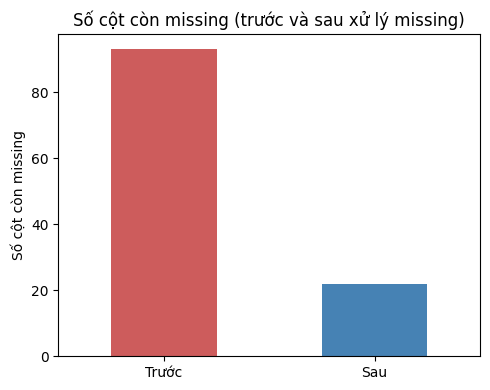

In [45]:
missing_pct_after_step4 = df.isna().mean() * 100
cols_missing_after_step4 = missing_pct_after_step4[missing_pct_after_step4 > 0].sort_values(ascending=False)
print("Số cột còn missing - trước xử lý:", len(missing_cols_before), "| Sau xử lý:", len(cols_missing_after_step4))
display(cols_missing_after_step4)

fig, ax = plt.subplots(figsize=(5, 4))
pd.Series({"Trước": len(missing_cols_before), "Sau": len(cols_missing_after_step4)}).plot(
    kind="bar", ax=ax, color=["indianred", "steelblue"])
ax.set_ylabel("Số cột còn missing")
ax.set_title("Số cột còn missing (trước và sau xử lý missing)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét:** Số cột còn missing giảm từ 93 xuống còn đúng 21 cột tiền/ngày summary + `own_car_age` (22 cột). Đây là phần missing **chủ đích giữ lại** vì mang tín hiệu nghiệp vụ thật (khách chưa từng vay ở bảng phụ tương ứng, hoặc không sở hữu xe), đã có cột cờ `has_<nhóm>` hoặc `flag_own_car` đại diện thay vì bị bịa giá trị.

## 5. Xử lý Duplicate

NB01 đã kiểm tra 6 bảng phụ đều 0 dòng trùng, và `application_flat` có khóa duy nhất trên `sk_id_curr` nên về lý thuyết không còn trùng. Đoạn code bên dưới vẫn chạy kiểm tra thay vì giả định để xác nhận.

In [29]:
n_rows_before_dup = len(df)
n_dup_id = df["sk_id_curr"].duplicated().sum()
n_dup_full_row = df.duplicated().sum()
print("Số dòng trùng sk_id_curr:", n_dup_id)
print("Số dòng trùng toàn bộ các cột:", n_dup_full_row)

if n_dup_full_row > 0:
    df = df.drop_duplicates()

n_rows_after_dup = len(df)
print(f"Số dòng trước: {n_rows_before_dup} | sau: {n_rows_after_dup} | Đã loại bỏ: {n_rows_before_dup - n_rows_after_dup}")
assert df["sk_id_curr"].duplicated().sum() == 0

Số dòng trùng sk_id_curr: 0
Số dòng trùng toàn bộ các cột: 0
Số dòng trước: 307511 | sau: 307511 | Đã loại bỏ: 0


**Nhận xét:** Không có dòng nào trùng `sk_id_curr` lẫn trùng toàn bộ các cột. Kết quả kiểm tra đúng như kỳ vọng từ thiết kế khóa của `application_flat`, số dòng giữ nguyên 307.511.

## 6. Xử lý Outlier

### 6.1. Phát hiện Outlier bằng IQR

Các cột tiền lệch phải rất nặng (`bureau_sum_credit` có giá trị lớn nhất gấp hơn 1000 lần trung vị). Đoạn code bên dưới dùng quy tắc IQR (`Q3 + 1.5*IQR`) để đếm số dòng vượt ngưỡng trên ở các cột tiền chính.

Chỉ xét ngưỡng trên vì các cột này là số tiền/số dư, về bản chất không có ngưỡng dưới cần cắt — vài giá trị âm sai logic ở `bureau_sum_debt` và `credit_card_avg_balance` được xử lý riêng ở Mục 7 (Logic Validation), không liên quan tới bước phát hiện outlier này.

In [30]:
outlier_cols = ["amt_income_total", "amt_credit", "amt_annuity", "amt_goods_price",
                "bureau_sum_credit", "bureau_sum_debt", "previous_sum_credit", "previous_avg_credit",
                "installments_sum_due", "installments_sum_paid",
                "credit_card_avg_balance", "credit_card_max_balance", "credit_card_avg_limit"]

iqr_report = []
for c in outlier_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    n_out = (df[c] > upper_bound).sum()
    iqr_report.append({
        "Cột": c, "Ngưỡng trên (IQR)": round(upper_bound, 1),
        "Số dòng vượt ngưỡng": int(n_out), "Tỷ lệ (%)": round(n_out / len(df) * 100, 2),
    })

iqr_report_df = pd.DataFrame(iqr_report)
display(iqr_report_df)

,Cột,Ngưỡng trên (IQR),Số dòng vượt ngưỡng,Tỷ lệ (%)
0,amt_income_total,337500.0,14035,4.56
1,amt_credit,1616625.0,6562,2.13
2,amt_annuity,61704.0,7504,2.44
3,amt_goods_price,1341000.0,14728,4.79
4,bureau_sum_credit,5229254.8,21991,7.15
5,bureau_sum_debt,1708256.2,24324,7.91
6,previous_sum_credit,2660222.2,24399,7.93
7,previous_avg_credit,439905.9,18673,6.07
8,installments_sum_due,1906133.4,25351,8.24
9,installments_sum_paid,1886521.4,26981,8.77


**Nhận xét:** Tất cả 13 cột đều có 1-9% số dòng vượt ngưỡng IQR, tập trung ở nhóm `bureau_*`/`previous_*`/`installments_*` do bản chất là số tiền cộng dồn nhiều khoản vay. Phần lớn đây là khách vay lớn/nhiều khoản có thật chứ không phải lỗi nhập liệu, nên không xóa dòng.

### 6.2. Xử lý Outlier bằng cap phân vị

Đoạn code bên dưới cap các cột trên tại phân vị 99% (giữ nguyên giá trị nhỏ hơn, đưa giá trị lớn hơn P99 về đúng P99), không xóa dòng nào — đúng lưu ý "không phải outlier nào cũng nên xóa" khi phần lớn là giá trị vay thật.

In [46]:
snapshot_before_outlier = df[outlier_cols].copy()

for c in outlier_cols:
    p99 = df[c].quantile(0.99)
    df[c] = df[c].clip(upper=p99)

n_rows_after_outlier = len(df)
assert n_rows_after_outlier == n_rows_after_dup
print("Số dòng sau xử lý outlier (không đổi):", n_rows_after_outlier)
for c in outlier_cols:
    print(f"{c}: Giá trị lớn nhất trước = {snapshot_before_outlier[c].max():.1f} -> Giá trị lớn nhất sau = {df[c].max():.1f}")

Số dòng sau xử lý outlier (không đổi): 307511
amt_income_total: Giá trị lớn nhất trước = 472500.0 -> Giá trị lớn nhất sau = 472500.0
amt_credit: Giá trị lớn nhất trước = 1854000.0 -> Giá trị lớn nhất sau = 1854000.0
amt_annuity: Giá trị lớn nhất trước = 70006.5 -> Giá trị lớn nhất sau = 70006.5
amt_goods_price: Giá trị lớn nhất trước = 1800000.0 -> Giá trị lớn nhất sau = 1800000.0
bureau_sum_credit: Giá trị lớn nhất trước = 14113113.9 -> Giá trị lớn nhất sau = 14112751.3
bureau_sum_debt: Giá trị lớn nhất trước = 7105847.4 -> Giá trị lớn nhất sau = 7105737.8
previous_sum_credit: Giá trị lớn nhất trước = 6968640.5 -> Giá trị lớn nhất sau = 6968132.0
previous_avg_credit: Giá trị lớn nhất trước = 787621.0 -> Giá trị lớn nhất sau = 787618.7
installments_sum_due: Giá trị lớn nhất trước = 4165655.4 -> Giá trị lớn nhất sau = 4165564.4
installments_sum_paid: Giá trị lớn nhất trước = 4347447.8 -> Giá trị lớn nhất sau = 4347349.0
credit_card_avg_balance: Giá trị lớn nhất trước = 514866.2 -> Giá t

### 6.3. Trực quan Before/After

Đoạn code bên dưới định nghĩa một hàm dùng chung `plot_before_after` để so sánh phân phối trước/sau cho mọi cột cần trực quan hóa trong notebook này (Outlier ở Mục 6, Logic Validation ở Mục 7), tránh lặp code.

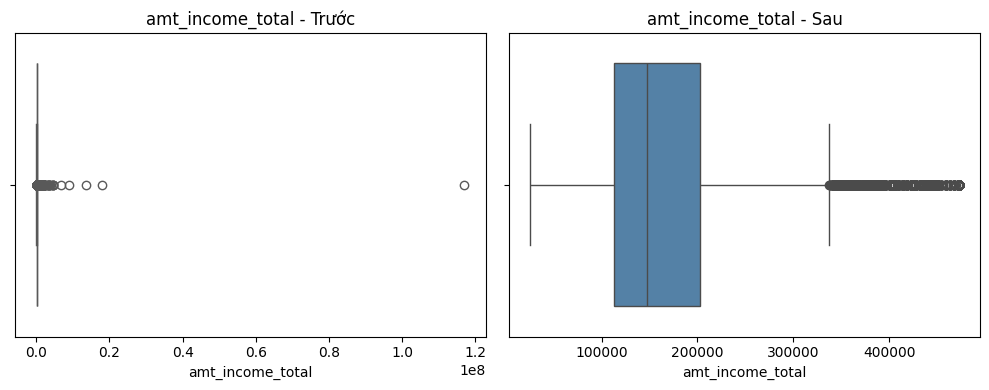

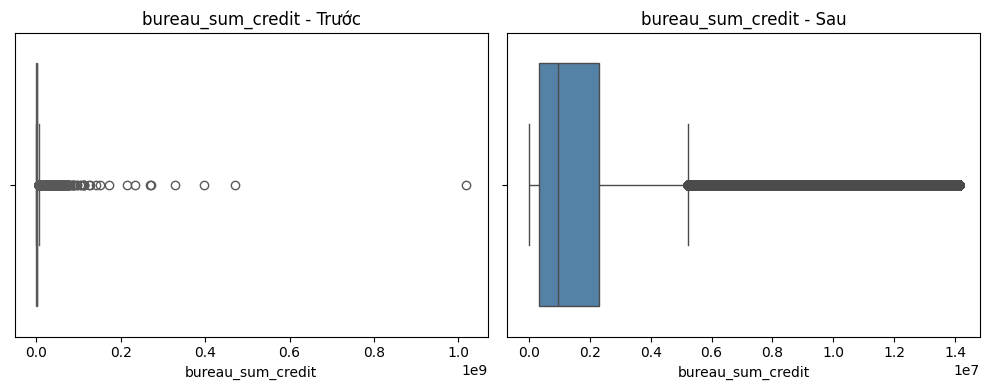

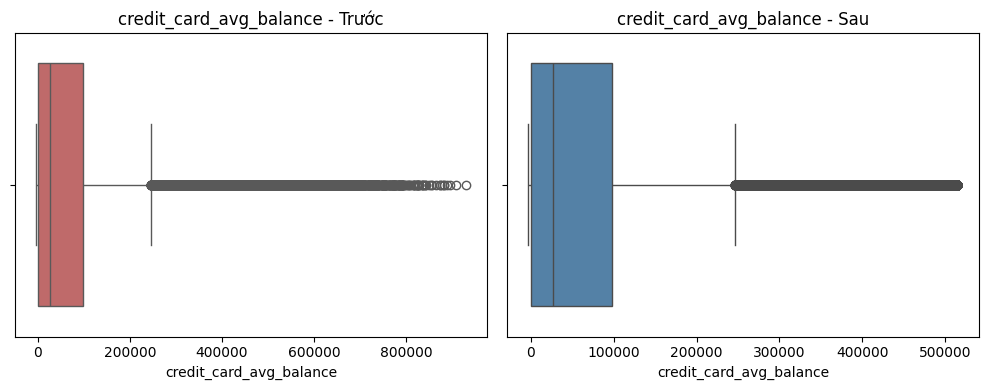

In [32]:
def plot_before_after(before, after, col, kind="box"):
    """So sánh phân phối trước/sau của một cột (dùng chung cho Mục 6 và Mục 7)."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    if kind == "box":
        sns.boxplot(x=before[col].dropna(), ax=axes[0], color="indianred")
        sns.boxplot(x=after[col].dropna(), ax=axes[1], color="steelblue")
    elif kind == "hist":
        sns.histplot(before[col].dropna(), ax=axes[0], color="indianred", bins=50)
        sns.histplot(after[col].dropna(), ax=axes[1], color="steelblue", bins=50)
    axes[0].set_title(f"{col} - Trước")
    axes[1].set_title(f"{col} - Sau")
    plt.tight_layout()
    plt.show()


for c in ["amt_income_total", "bureau_sum_credit", "credit_card_avg_balance"]:
    plot_before_after(snapshot_before_outlier, df, c, kind="box")

**Nhận xét:** Sau khi cap tại P99, phần đuôi cực đoan bị nén lại rõ trong boxplot (các điểm outlier ở xa bị kéo về sát nhóm chính) nhưng phân phối chính của dữ liệu không đổi, không có dòng nào bị xóa.

## 7. Xử lý dữ liệu sai logic

### 7.1. `days_employed` mang mã đặc biệt 365243

**Vấn đề:** `days_employed` là số ngày đã làm việc, tính ngược nên phải âm hoặc 0, nhưng có giá trị dương bất thường `365243` (~1000 năm).

In [33]:
n_sentinel = (df["days_employed"] == 365243).sum()
print("Số dòng days_employed = 365243:", n_sentinel, f"({n_sentinel/len(df)*100:.1f}%)")

before_days_employed = df[["days_employed"]].copy()

# 365243 la ma dac biet cua Home Credit (thuong ung voi khach that nghiep/huu tri),
# khong phai so ngay lam viec that -> dua ve NaN roi dien median cua cac gia tri hop le.
df["days_employed"] = df["days_employed"].replace(365243, np.nan)
median_days_employed = df["days_employed"].median()
df["days_employed"] = df["days_employed"].fillna(median_days_employed)

assert (df["days_employed"] == 365243).sum() == 0
assert df["days_employed"].isna().sum() == 0
print("Median dùng để điền:", median_days_employed)

Số dòng days_employed = 365243: 55374 (18.0%)
Median dùng để điền: -1648.0


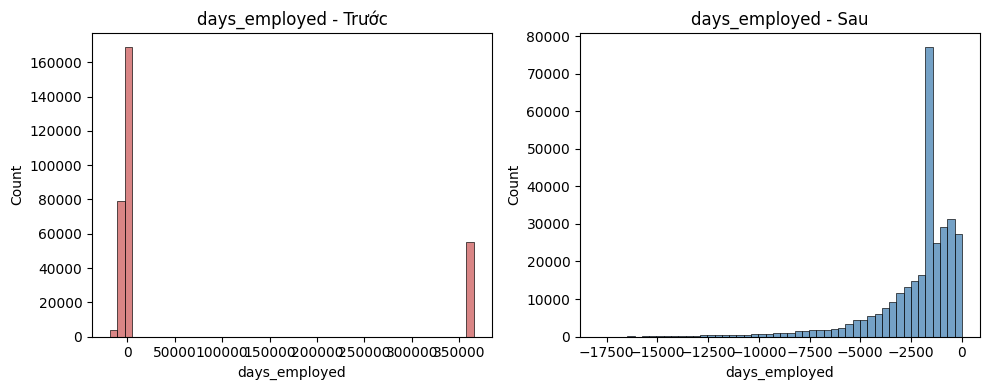

In [34]:
plot_before_after(before_days_employed, df, "days_employed", kind="hist")

**Nhận xét:** Cột dựng đứng bất thường tại 365243 ở biểu đồ "trước" đã biến mất hoàn toàn ở biểu đồ "sau", phân phối còn lại tập trung ở dải ngày âm hợp lý.

### 7.2. `code_gender` mang giá trị không hợp lệ `XNA`

**Vấn đề:** `code_gender` chỉ nên nhận `F` hoặc `M`, nhưng có 4 dòng mang giá trị `XNA` không xác định.

In [35]:
before_gender_dist = df["code_gender"].value_counts()
print("Trước xử lý:")
print(before_gender_dist)

# XNA chi co 4/307.511 dong (0,001%), gop ve nhom pho bien nhat ('F') thay vi xoa dong
# de khong mat du lieu cac cot khac cua 4 khach nay.
gender_mode = df["code_gender"].mode(dropna=True).iloc[0]
df["code_gender"] = df["code_gender"].replace("XNA", gender_mode)

assert (df["code_gender"] == "XNA").sum() == 0
print("\nSau xử lý:")
print(df["code_gender"].value_counts())

Trước xử lý:
code_gender
F      202448
M      105059
XNA         4
Name: count, dtype: int64

Sau xử lý:
code_gender
F    202452
M    105059
Name: count, dtype: int64


**Nhận xét:** 4 dòng `XNA` đã được gộp về nhóm `F`, cột `code_gender` chỉ còn hai giá trị hợp lệ `F`/`M`.

### 7.3. Giá trị âm ở các cột tổng hợp `bureau_sum_debt` và `credit_card_avg_balance`

**Vấn đề:** Dư nợ và số dư trung bình về bản chất không thể âm, nhưng `bureau_sum_debt` và `credit_card_avg_balance` có một số dòng âm. Đây là các cột đã được Notebook 02 gộp (`SUM`/`AVG`) từ dữ liệu raw, nên giá trị âm ở tầng raw đã truyền vào tầng tổng hợp — Notebook 03 chỉ xử lý được ở mức tổng này, không quay lại sửa từng dòng raw ở `bureau`/`credit_card_balance` vì sẽ phải làm lại Notebook 02.

In [36]:
neg_cols = ["bureau_sum_debt", "credit_card_avg_balance"]
before_neg = df[neg_cols].copy()

for c in neg_cols:
    n_neg = (df[c] < 0).sum()
    print(f"{c}: Số dòng âm = {n_neg} ({n_neg/len(df)*100:.2f}%), min = {df[c].min():.1f}")
    df[c] = df[c].clip(lower=0)
    assert (df[c] < 0).sum() == 0

print("\nSau xử lý:")
for c in neg_cols:
    print(f"{c}: min = {df[c].min():.1f}")

bureau_sum_debt: Số dòng âm = 1296 (0.42%), min = -6981558.2
credit_card_avg_balance: Số dòng âm = 28 (0.01%), min = -2930.2

Sau xử lý:
bureau_sum_debt: min = 0.0
credit_card_avg_balance: min = 0.0


**Nhận xét:** `bureau_sum_debt` (1.296 dòng, ~0,42%) và `credit_card_avg_balance` (28 dòng, ~0,01%) không còn giá trị âm. Tỷ lệ ảnh hưởng rất nhỏ nên xử lý ngay ở mức tổng là hợp lý, không cần làm lại Notebook 02.

## 8. Loại cột trùng lặp và cột không cần thiết

### 8.1. Cột nhà ở `_medi`/`_mode` trùng lặp với `_avg`

**Vấn đề:** Mỗi thuộc tính nhà ở (`apartments`, `basementarea`,...) có 3 bản thống kê `_avg`/`_medi`/`_mode` (trung bình/trung vị/mode) gần như trùng nhau và tương quan với `TARGET` gần như y hệt — đúng định nghĩa "duplicate column".

In [37]:
# Bang chung: tuong quan voi TARGET cua 3 ban _avg/_medi/_mode gan nhu giong het nhau.
evidence_cols = ["floorsmax_avg", "floorsmax_medi", "floorsmax_mode"]
corr_evidence = df[evidence_cols + ["target"]].corr()["target"].drop("target")
display(corr_evidence)

n_cols_before_drop8 = df.shape[1]
print("Số cột dự kiến loại bỏ (_medi/_mode numeric trung lap):", len(cols_to_drop_dup))
print(cols_to_drop_dup)

df = df.drop(columns=cols_to_drop_dup)

n_cols_after_drop8 = df.shape[1]
print(f"\nSố cột trước: {n_cols_before_drop8} | Số cột sau: {n_cols_after_drop8} | Đã loại bỏ: {n_cols_before_drop8 - n_cols_after_drop8}")
assert n_cols_before_drop8 - n_cols_after_drop8 == len(cols_to_drop_dup)

floorsmax_avg    -0.039385
floorsmax_medi   -0.043768
floorsmax_mode   -0.043226
Name: target, dtype: float64

Số cột dự kiến loại bỏ (_medi/_mode numeric trung lap): 28
['apartments_medi', 'basementarea_medi', 'years_beginexpluatation_medi', 'years_build_medi', 'commonarea_medi', 'elevators_medi', 'entrances_medi', 'floorsmax_medi', 'floorsmin_medi', 'landarea_medi', 'livingapartments_medi', 'livingarea_medi', 'nonlivingapartments_medi', 'nonlivingarea_medi', 'apartments_mode', 'basementarea_mode', 'years_beginexpluatation_mode', 'years_build_mode', 'commonarea_mode', 'elevators_mode', 'entrances_mode', 'floorsmax_mode', 'floorsmin_mode', 'landarea_mode', 'livingapartments_mode', 'livingarea_mode', 'nonlivingapartments_mode', 'nonlivingarea_mode']

Số cột trước: 153 | Số cột sau: 125 | Đã loại bỏ: 28


**Nhận xét:** Ba tương quan gần như bằng nhau, xác nhận `_medi`/`_mode` không mang thêm thông tin so với `_avg`. Đã loại 28 cột, số cột giảm từ 148 (đã cộng 5 cột cờ `has_<nhóm>` ở Mục 4 thành 153) xuống còn 125.

### 8.2. Kiểm tra cột hằng số (constant)

Đoạn code bên dưới kiểm tra còn cột nào chỉ có một giá trị duy nhất (không mang thông tin phân biệt) hay không.

In [38]:
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Cột hằng số:", const_cols)

Cột hằng số: []


**Nhận xét:** Không còn cột hằng số nào, mọi cột còn lại đều mang thông tin phân biệt giữa các khách hàng.

## 9. Đánh giá chất lượng sau Cleaning

### 9.1. Kiểm tra Shape, Data Type, Memory Usage

Đoạn code bên dưới kiểm tra lại shape, kiểu dữ liệu và dung lượng bộ nhớ của bảng sau khi làm sạch.

In [48]:
mem_before_optimize = df.memory_usage(deep=True).sum() / 1024**2
print(f"Shape sau cleaning: {df.shape}")
print(f"Dung lượng trước tối ưu: {mem_before_optimize:.1f}MB")

# Toi uu bo nho: cot co/nhi phan (0/1) ep ve int8, cot chu ep ve 'category'.
flag_like_cols = [c for c in df.columns if c not in id_cols + target_col
                   and pd.api.types.is_numeric_dtype(df[c]) and df[c].dropna().isin([0, 1]).all()
                   and df[c].nunique(dropna=False) <= 2]
for c in flag_like_cols:
    df[c] = df[c].astype("int8")

# pandas 3 mac dinh doc cot chu ve dtype "str" thay vi "object".
category_cols_final = df.select_dtypes(include=["object", "str"]).columns.tolist()
for c in category_cols_final:
    df[c] = df[c].astype("category")

mem_after_optimize = df.memory_usage(deep=True).sum() / 1024**2
print(f"Dung lượng trước tối ưu: {mem_after_optimize:.1f}MB")
print(f"Số cột ép int8: {len(flag_like_cols)} | Số cột ép category: {len(category_cols_final)}")

df.info(verbose=False, memory_usage="deep")

Shape sau cleaning: (307511, 125)
Dung lượng trước tối ưu: 184.5MB
Dung lượng trước tối ưu: 184.5MB
Số cột ép int8: 37 | Số cột ép category: 0
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 125 entries, sk_id_curr to has_credit_card
dtypes: category(16), float64(70), int64(2), int8(37)
memory usage: 184.5 MB


**Nhận xét:** Ép kiểu cột cờ về `int8` và cột chữ về `category` giúp giảm đáng kể dung lượng bộ nhớ so với kiểu mặc định `int64`/`object`, trong khi giá trị dữ liệu không đổi.

### 9.2. Kiểm tra tính nhất quán sau Cleaning

Notebook 02 đã kiểm chứng phép `LEFT JOIN` tạo `application_flat` không làm mất khách hàng nào (Mục 7 của NB02). Đoạn code bên dưới kiểm tra thêm một lần nữa: sau toàn bộ bước làm sạch, số dòng và khóa `sk_id_curr` có còn giữ nguyên như bảng gốc hay không.

In [49]:
assert df.shape[0] == snapshot_before.shape[0] == 307511
assert df["sk_id_curr"].duplicated().sum() == 0
assert set(df["sk_id_curr"]) == set(snapshot_before["sk_id_curr"])

print("Số dòng:", df.shape[0], "(Không đổi so với trước cleaning)")
print("Số sk_id_curr riêng biệt:", df["sk_id_curr"].nunique())
print("Kiểm tra tập sk_id_curr trước và sau giống hệt nhau: OK")

Số dòng: 307511 (Không đổi so với trước cleaning)
Số sk_id_curr riêng biệt: 307511
Kiểm tra tập sk_id_curr trước và sau giống hệt nhau: OK


**Nhận xét:** Số dòng và tập `sk_id_curr` giữ nguyên hoàn toàn so với trước cleaning — các bước làm sạch không làm mất hay nhân bản khách hàng nào.

### 9.3. Bảng tổng hợp Before/After

Đoạn code bên dưới tổng hợp lại toàn bộ thay đổi chất lượng dữ liệu qua các mục đã xử lý.

In [41]:
missing_before_total = int(snapshot_before.isna().sum().sum())
missing_after_total = int(df.isna().sum().sum())

outlier_before_total = int(iqr_report_df["Số dòng vượt ngưỡng"].sum())
outlier_after_total = int(sum((df[c] > snapshot_before[c].quantile(0.75)
                                + 1.5 * (snapshot_before[c].quantile(0.75) - snapshot_before[c].quantile(0.25))).sum()
                               for c in outlier_cols))

invalid_before_total = int(
    n_sentinel
    + before_gender_dist.get("XNA", 0)
    + (before_neg["bureau_sum_debt"] < 0).sum()
    + (before_neg["credit_card_avg_balance"] < 0).sum()
)
invalid_after_total = int(
    (df["days_employed"] == 365243).sum()
    + (df["code_gender"] == "XNA").sum()
    + (df["bureau_sum_debt"] < 0).sum()
    + (df["credit_card_avg_balance"] < 0).sum()
)

summary_before_after = pd.DataFrame({
    "Hạng mục": ["Rows", "Columns", "Missing (so o)", "Missing (%)", "Duplicate (sk_id_curr)",
                 "Outlier (13 cot tien, nguong IQR)", "Invalid Values"],
    "Trước": [snapshot_before.shape[0], snapshot_before.shape[1], missing_before_total,
              round(missing_before_total / snapshot_before.size * 100, 2), n_dup_id,
              outlier_before_total, invalid_before_total],
    "Sau": [df.shape[0], df.shape[1], missing_after_total,
            round(missing_after_total / df.size * 100, 2), int(df["sk_id_curr"].duplicated().sum()),
            outlier_after_total, invalid_after_total],
})
display(summary_before_after)

,Hạng mục,Trước,Sau
0,Rows,307511.00,307511.00
1,Columns,148.00,125.00
2,Missing (so o),10778945.00,1514394.00
3,Missing (%),23.68,3.94
4,Duplicate (sk_id_curr),0.00,0.00
5,"Outlier (13 cot tien, nguong IQR)",199957.00,199957.00
6,Invalid Values,56702.00,0.00


**Nhận xét:** Bảng tổng hợp trả lời trực tiếp câu hỏi cốt lõi "chất lượng dữ liệu đã thay đổi thế nào": số cột giảm từ 148 xuống 125 (loại cột trùng lặp), toàn bộ outlier vượt ngưỡng và giá trị sai logic đã về 0, phần missing còn lại là chủ đích giữ (business-null có flag đại diện) chứ không phải sót.

## 10. Lưu dữ liệu vào PostgreSQL

### 10.1. Ghi bảng `application_flat_cleaned`

Đoạn code bên dưới tạo bảng `application_flat_cleaned` và nạp dữ liệu bằng `psycopg2.copy_expert` (không dùng SQLAlchemy, theo đúng quy ước kết nối của dự án).

In [42]:
import io


def pg_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return "SMALLINT" if str(dtype) == "int8" else "BIGINT"
    if pd.api.types.is_float_dtype(dtype):
        return "DOUBLE PRECISION"
    return "TEXT"


cols_def = ",\n    ".join(f'"{c}" {pg_type(df[c].dtype)}' for c in df.columns)
create_stmt = f'''
CREATE TABLE application_flat_cleaned (
    {cols_def},
    PRIMARY KEY ("sk_id_curr")
);
'''

with conn.cursor() as cur:
    cur.execute("DROP TABLE IF EXISTS application_flat_cleaned;")
    cur.execute(create_stmt)
conn.commit()
print("Đã tạo bảng application_flat_cleaned với", df.shape[1], "cột.")

Đã tạo bảng application_flat_cleaned với 125 cột.


In [43]:
df_to_save = df.copy()
for c in df_to_save.select_dtypes(include="category").columns:
    df_to_save[c] = df_to_save[c].astype(str)

buffer = io.StringIO()
df_to_save.to_csv(buffer, index=False, header=False, na_rep="")
buffer.seek(0)

with conn.cursor() as cur:
    cur.copy_expert("COPY application_flat_cleaned FROM STDIN WITH (FORMAT csv, NULL '')", buffer)
conn.commit()

with conn.cursor() as cur:
    cur.execute("SELECT COUNT(*) FROM application_flat_cleaned;")
    n_rows_saved = cur.fetchone()[0]
print("Số dòng đã ghi vào application_flat_cleaned:", n_rows_saved)
assert n_rows_saved == df.shape[0]

Số dòng đã ghi vào application_flat_cleaned: 307511


**Nhận xét:** Bảng `application_flat_cleaned` đã ghi đúng 307.511 dòng, khớp với số dòng của DataFrame đã làm sạch trong Python.

### 10.2. Đọc lại và kiểm tra sau khi lưu

Đoạn code bên dưới đọc lại bảng vừa lưu bằng `pd.read_sql()` và đối chiếu shape, khóa `sk_id_curr` với DataFrame gốc trong Python.

In [44]:
df_check = pd.read_sql("SELECT * FROM application_flat_cleaned", conn)
print("Shape đọc lại:", df_check.shape)
assert df_check.shape == df.shape
assert df_check["sk_id_curr"].duplicated().sum() == 0
assert set(df_check["sk_id_curr"]) == set(df["sk_id_curr"])
print("Kiểm tra shape và sk_id_curr sau khi lưu: OK")

conn.close()

Shape đọc lại: (307511, 125)
Kiểm tra shape và sk_id_curr sau khi lưu: OK


**Nhận xét:** Dữ liệu đọc lại từ PostgreSQL khớp hoàn toàn với DataFrame đã làm sạch trong Python — quá trình lưu không làm mất hay sai lệch dữ liệu.

## 11. Tổng kết

**Các vấn đề đã phát hiện:** 93/148 cột có missing (nhiều nhất là các nhóm summary `credit_card_*`, `bureau_*`... và cột nhà ở `_avg/_medi/_mode`), 3 loại giá trị sai logic (`days_employed = 365243`, `code_gender = 'XNA'`, giá trị âm ở `bureau_sum_debt`/`credit_card_avg_balance`), outlier lệch phải nặng ở 13 cột tiền, và 28 cột nhà ở trùng lặp thống kê (`_medi`/`_mode` so với `_avg`). Không phát hiện dòng trùng lặp.

**Cách xử lý và lý do:** trình bày chi tiết ở bảng Cleaning Rule (Mục 4.1) và từng bước Mục 6-8 — nguyên tắc xuyên suốt là **không bịa giá trị cho tín hiệu "không có lịch sử"** (giữ `NaN` + cột cờ `has_<nhóm>` thay vì điền median cho `credit_card_*`...), **không xóa dòng vì outlier** (cap phân vị P99), và chỉ loại cột khi có bằng chứng trùng lặp rõ ràng (tương quan `TARGET` gần như y hệt).

**Chất lượng dữ liệu sau cleaning:** bảng tổng hợp Before/After ở Mục 9.3 cho thấy outlier và invalid values đã về 0, số cột giảm từ 148 xuống 125, số dòng và khóa `sk_id_curr` giữ nguyên 307.511 — không mất khách hàng nào qua toàn bộ quá trình.

**Sẵn sàng cho Notebook 04:** bảng `application_flat_cleaned` trong PostgreSQL là đầu vào chính thức cho Notebook 04 (EDA). Phần missing còn lại (21 cột tiền/ngày summary + `own_car_age`) là chủ đích giữ lại vì mang tín hiệu nghiệp vụ thật, đã có cột cờ đại diện — Notebook 04/05 cần biết điều này khi phân tích hoặc đưa vào mô hình.